In [1]:
# !pip install aiomoex
# !pip install tinkoff-investments
# !pip install yfinance

In [2]:
# !pip install git+https://github.com/tinkoff/invest-python.git --no-deps
# !pip install tensorflow==2.15.0 scikit-learn matplotlib pandas
# !pip install cachetools deprecation python-dateutil
# Устанавливаем конкретную версию cachetools, которую просит Тинькофф
# !pip install "cachetools>=5.2.0,<6.0.0"
# !pip install dotenv
# !pip install fastparquet

# !pip uninstall -y pandas pyarrow
# !pip install "pandas>=2.0.0" "pyarrow>=11.0.0"
# !pip install seaborn

In [3]:
# !pip freeze > requirements.txt

Открытые вопросы:
* Стоит ли описывать варианты получения данных и причину выбора?

Что нужно сделать ближайшее:
* Выгрузить IMOEX индекс на периоде для сравнения (в идеале потом можно еще с открытием вкладов сравнить, но сложно кодом считать)
* Реализовать функции расчета индикаторов, которые необходимы будут для обучения


In [4]:
from tinkoff.invest import Client, AsyncClient, CandleInterval, SecurityTradingStatus, InstrumentStatus
from tinkoff.invest.services import InstrumentsService
from tinkoff.invest.utils import quotation_to_decimal, now
from tinkoff.invest.caching.instruments_cache.instruments_cache import InstrumentsCache

from tensorflow.keras import layers, models, optimizers
from sklearn.preprocessing import StandardScaler

import pyarrow
import pandas as pd
from pandas.tseries.offsets import DateOffset
from scipy import stats
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os
# import asyncio
import math

import time
from datetime import datetime, timezone, timedelta

from pathlib import Path
from typing import Optional

from dotenv import load_dotenv

import warnings
warnings.filterwarnings("ignore")

In [5]:
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

In [6]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

In [7]:
load_dotenv()

TOKEN = os.getenv("TOKEN")

In [8]:
TRAIN_MONTHS = 24  # Длительность обучения (2 года в статье)
TEST_MONTHS = 1    # Как часто переобучаем модель и тестируем (например, раз в месяц)
WINDOW_SIZE = 24   # Размер входного окна (24 свечи = 2 часа для 5-мин)
ALPHA = 2       # Порог волатильности для таргета
LEARNING_RATE = 0.0001
CONFIDENCE_THRESHOLD = 0.75

In [9]:
def clean_market_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Очищает данные от пропусков и нулевых значений.
    """
    df = df.copy()
    
    # 1. Заменяем чистые нули на NaN (в цене Close/Open нулей быть не может)
    # Делаем это только для колонок с ценами
    cols_to_fix = ['Open', 'High', 'Low', 'Close']
    for col in cols_to_fix:
        df[col] = df[col].replace(0, pd.NA)
    
    # 2. Сортируем по времени (важно для правильного заполнения "вперед")
    df = df.sort_values("DateTime")
    
    # 3. Forward Fill: заполняем пропуски последним известным значением
    df[cols_to_fix] = df[cols_to_fix].ffill()
    
    # 4. Backward Fill: на случай, если пропуски в самых первых строках
    df[cols_to_fix] = df[cols_to_fix].bfill()
    
    # 5. Обработка объема (Volume)
    # Для объема пропуски лучше заменять на 0, так как сделок просто не было
    df['Volume'] = df['Volume'].fillna(0)
    
    return df

In [10]:
def fill_time_gaps(df: pd.DataFrame, interval_name: str = "5min") -> pd.DataFrame:
    """
    Вставляет пропущенные временные интервалы (строки), которых нет в данных.
    """
    # Маппинг для метода resample
    resample_map = {
        "5min": "5min", "15min": "15min", "1hour": "h", "1day": "D"
    }
    freq = resample_map.get(interval_name, "5min")
    
    df = df.set_index("DateTime").sort_index()
    
    # Создаем полный индекс без дыр от начала до конца
    full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq=freq)
    
    # Переиндексируем (появятся строки с NaN там, где были дыры)
    df = df.reindex(full_range)
    df.index.name = "DateTime"
    
    # Заполняем пустоты
    df[['Open', 'High', 'Low', 'Close']] = df[['Open', 'High', 'Low', 'Close']].ffill()
    df['Volume'] = df['Volume'].fillna(0)
    
    return df.reset_index()

In [11]:
def add_technical_indicators(df: pd.DataFrame, 
                             sma_periods: list = [20, 50, 200],
                             ema_periods: list = [12, 26],
                             rsi_period: int = 14,
                             macd_fast: int = 12,
                             macd_slow: int = 26,
                             macd_signal: int = 9,
                             bb_period: int = 20,
                             cci_period: int = 20,
                             adx_period: int = 14,
                             roc_period: int = 12,
                             cmf_period: int = 20) -> pd.DataFrame:
    """
    Добавляет полный набор технических индикаторов (Lagging, Leading, Neutral).
    """
    df = df.copy()
    close = df['Close']
    high = df['High']
    low = df['Low']
    volume = df['Volume']
    
    # --- LAGGING INDICATORS ---
    
    # SMA & EMA
    for period in sma_periods:
        df[f'SMA_{period}'] = close.rolling(window=period).mean()
    for period in ema_periods:
        df[f'EMA_{period}'] = close.ewm(span=period, adjust=False).mean()
    
    # MACD
    ema_f = close.ewm(span=macd_fast, adjust=False).mean()
    ema_s = close.ewm(span=macd_slow, adjust=False).mean()
    df['MACD'] = ema_f - ema_s
    df['MACD_Signal'] = df['MACD'].ewm(span=macd_signal, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']
    
    # Bollinger Bands
    sma_bb = close.rolling(window=bb_period).mean()
    std_bb = close.rolling(window=bb_period).std()
    df['BB_Upper'] = sma_bb + (2 * std_bb)
    df['BB_Lower'] = sma_bb - (2 * std_bb)
    
    # --- LEADING INDICATORS ---
    
    # RSI
    delta = close.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=rsi_period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=rsi_period).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))
    
    # CCI (Commodity Channel Index)
    tp = (high + low + close) / 3
    sma_tp = tp.rolling(window=cci_period).mean()
    mad_tp = tp.rolling(window=cci_period).apply(lambda x: np.abs(x - x.mean()).mean())
    df['CCI'] = (tp - sma_tp) / (0.015 * mad_tp)
    
    # VWAP (Volume Weighted Average Price)
    # Считается накопительно, если данные внутри дня, или скользящим окном
    df['VWAP'] = (volume * (high + low + close) / 3).cumsum() / volume.cumsum()
    
    # OBV (On-Balance Volume)
    df['OBV'] = (np.sign(close.diff()) * volume).fillna(0).cumsum()
    
    # ADX (Average Directional Index)
    plus_dm = high.diff().where((high.diff() > low.diff().abs()) & (high.diff() > 0), 0)
    minus_dm = low.diff().abs().where((low.diff().abs() > high.diff()) & (low.diff().abs() > 0), 0)
    tr = pd.concat([high - low, (high - close.shift()).abs(), (low - close.shift()).abs()], axis=1).max(axis=1)
    atr = tr.rolling(window=adx_period).mean()
    plus_di = 100 * (plus_dm.rolling(window=adx_period).mean() / atr)
    minus_di = 100 * (minus_dm.rolling(window=adx_period).mean() / atr)
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
    df['ADX'] = dx.rolling(window=adx_period).mean()
    
    # ADL (Accumulation Distribution Line)
    mfm = ((close - low) - (high - close)) / (high - low)
    mfm = mfm.replace([np.inf, -np.inf], 0).fillna(0) # Защита от zero division если high==low
    df['ADL'] = (mfm * volume).cumsum()
    
    # CMF (Chaikin Money Flow)
    mfv = mfm * volume
    df['CMF'] = mfv.rolling(window=cmf_period).sum() / volume.rolling(window=cmf_period).sum()
    
    # --- NEUTRAL / MOMENTUM INDICATORS ---
    
    # ROC (Rate of Change)
    df['ROC'] = ((close - close.shift(roc_period)) / close.shift(roc_period)) * 100
    
    return df

In [12]:
def build_model(input_shape):
    model = models.Sequential([
        layers.Conv1D(64, kernel_size=3, padding='same', activation='relu', input_shape=input_shape),
        layers.MaxPooling1D(2),
        layers.Conv1D(128, kernel_size=3, padding='same', activation='relu'),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(3, activation='softmax') 
    ])
    
    # Использование legacy оптимизатора для ускорения на M1/M2/M3
    try:
        opt = optimizers.legacy.Adam(learning_rate=LEARNING_RATE)
        print("Используется оптимизатор legacy.Adam для Mac")
    except AttributeError:
        opt = optimizers.Adam(learning_rate=LEARNING_RATE)
        print("Используется стандартный Adam")

    model.compile(
        optimizer=opt, 
        loss='sparse_categorical_crossentropy', 
        metrics=['accuracy']
    )
    return model

In [13]:
def create_tensors(df, window_size=WINDOW_SIZE, alpha=ALPHA):
    """
    Создает X (тензоры для CNN) и y (таргеты по волатильности).
    """
    df = df.copy().sort_values("DateTime")
    
    # Расчет таргета как в статье
    returns = df['Close'].pct_change()
    volatility = returns.rolling(window=10).std()
    # Изменение цены через 24 свечи (2 часа для 5-мин интервала)
    future_change = (df['Close'].shift(-window_size) - df['Close']) / df['Close']
    
    conditions = [
        (future_change >= alpha * volatility), # Up (1)
        (future_change <= -alpha * volatility) # Down (2)
    ]
    df['Target'] = np.select(conditions, [1, 2], default=0) # Flat (0)
    
    # Фичи: OHLCV (как базовый набор из статьи)
    features = ['Open', 'High', 'Low', 'Close', 'Volume']
    data_x = df[features].values
    data_y = df['Target'].values
    dates = df['DateTime'].values
    prices = df['Close'].values

    X, y, out_dates, out_prices = [], [], [], []

    for i in range(window_size, len(df) - window_size):
        # Извлекаем окно
        window = data_x[i-window_size:i]
        
        # Локальная нормализация окна (Z-score) для стабильности CNN
        scaler = StandardScaler()
        norm_window = scaler.fit_transform(window)
        
        X.append(norm_window)
        y.append(data_y[i])
        out_dates.append(dates[i])
        out_prices.append(prices[i])

    return np.array(X), np.array(y), np.array(out_dates), np.array(out_prices)

In [14]:
def run_backtest_with_fine_tuning(df, confidence_threshold = CONFIDENCE_THRESHOLD):
    # Добавьте это в начало функции run_backtest_with_fine_tuning
    total_months = (df['DateTime'].max() - df['DateTime'].min()).days // 30
    if total_months < TRAIN_MONTHS + TEST_MONTHS:
        print(f"ВНИМАНИЕ: Недостаточно данных! Всего месяцев: {total_months}, нужно минимум: {TRAIN_MONTHS + TEST_MONTHS}")
    else:
        print(f"Данных достаточно. Обучение: {TRAIN_MONTHS} мес. Проверка составит примерно {total_months - TRAIN_MONTHS} мес.")
        
    # Используем более жесткие параметры при создании тензоров
    X_all, y_all, dates_all, prices_all = create_tensors(df, alpha=ALPHA) 
    dt_index = pd.to_datetime(dates_all)
    
    start_date = dt_index.min()
    current_test_start = start_date + DateOffset(months=TRAIN_MONTHS)
    
    model = build_model(input_shape=(WINDOW_SIZE, 5))
    
    # print("Первичное обучение...")
    initial_mask = (dt_index >= start_date) & (dt_index < current_test_start)
    # Используем class_weight, так как хороших сигналов теперь мало (они редкие)
    model.fit(X_all[initial_mask], y_all[initial_mask], epochs=15, batch_size=32, verbose=1)
    
    all_preds = []
    confidence_threshold = CONFIDENCE_THRESHOLD # Фильтр "уверенности"

    while current_test_start < dt_index.max():
        test_end = current_test_start + DateOffset(months=TEST_MONTHS)
        test_mask = (dt_index >= current_test_start) & (dt_index < test_end)
        
        X_test, y_test = X_all[test_mask], y_all[test_mask]
        if len(X_test) == 0: break
            
        probs = model.predict(X_test, verbose=0)
        
        # ЛОГИКА ФИЛЬТРАЦИИ:
        # p[0] - Flat, p[1] - Buy, p[2] - Sell
        final_classes = []
        for p in probs:
            if p[1] > CONFIDENCE_THRESHOLD:
                final_classes.append(1)
            elif p[2] > CONFIDENCE_THRESHOLD:
                final_classes.append(2)
            else:
                final_classes.append(0) # Игнорируем неуверенные сигналы
        
        chunk_results = pd.DataFrame({
            'DateTime': dates_all[test_mask],
            'Price': prices_all[test_mask],
            'Actual': y_test,
            'Predicted': final_classes
        })
        all_preds.append(chunk_results)
        
        # print(f"Update: {current_test_start.date()} | Сделок в периоде: {sum(np.array(final_classes) != 0)}")
        
        # Дообучение только на реальных движениях (где y != 0)
        model.fit(X_test, y_test, epochs=1, batch_size=32, verbose=0)
        current_test_start = test_end

    return pd.concat(all_preds)

In [26]:
df_YDEX = pd.read_parquet('data/YDEX_5min.parquet')
df_YDEX = df_YDEX[df_YDEX['DateTime'] < '2026-01-01']
df_YDEX = fill_time_gaps(df_YDEX)
df_YDEX = clean_market_data(df_YDEX)

In [27]:
X_all, y_all, dates_all, prices_all = create_tensors(df_YDEX, window_size=WINDOW_SIZE, alpha=ALPHA)

final_results = run_backtest_with_fine_tuning(df_YDEX)

Данных достаточно. Обучение: 24 мес. Проверка составит примерно 71 мес.
Используется оптимизатор legacy.Adam для Mac
Epoch 1/15
6579/6579 [==============================] - 13s 2ms/step - loss: 0.4381 - accuracy: 0.8230
Epoch 2/15
6579/6579 [==============================] - 13s 2ms/step - loss: 0.4129 - accuracy: 0.8289
Epoch 3/15
6579/6579 [==============================] - 14s 2ms/step - loss: 0.4055 - accuracy: 0.8333
Epoch 4/15
6579/6579 [==============================] - 14s 2ms/step - loss: 0.3986 - accuracy: 0.8381
Epoch 5/15
6579/6579 [==============================] - 14s 2ms/step - loss: 0.3912 - accuracy: 0.8438
Epoch 6/15
6579/6579 [==============================] - 14s 2ms/step - loss: 0.3825 - accuracy: 0.8503
Epoch 7/15
6579/6579 [==============================] - 14s 2ms/step - loss: 0.3732 - accuracy: 0.8569
Epoch 8/15
6579/6579 [==============================] - 14s 2ms/step - loss: 0.3629 - accuracy: 0.8643
Epoch 9/15
6579/6579 [==============================] - 14s

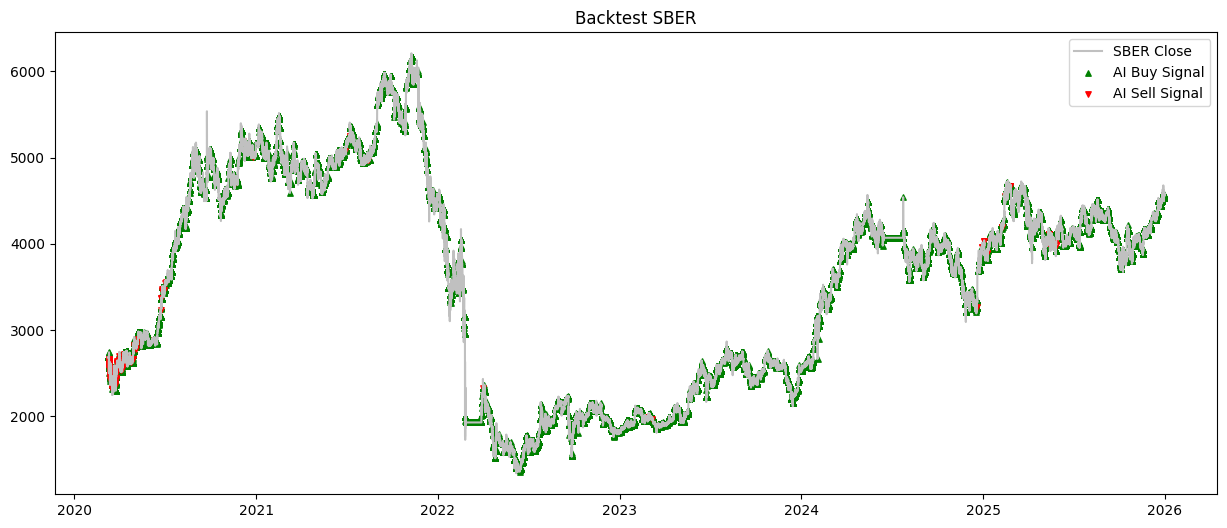

In [28]:
if not final_results.empty:
    # Визуализация (как в предыдущем ответе)
    plt.figure(figsize=(15, 6))
    plt.plot(final_results['DateTime'], final_results['Price'], color='silver', label='SBER Close')
    
    # Сигналы
    up = final_results[final_results['Predicted'] == 1]
    down = final_results[final_results['Predicted'] == 2]
    
    plt.scatter(up['DateTime'], up['Price'], marker='^', color='green', s=15, label='AI Buy Signal')
    plt.scatter(down['DateTime'], down['Price'], marker='v', color='red', s=15, label='AI Sell Signal')
    
    plt.title(f"Backtest SBER")
    plt.legend()
    plt.show()

In [ ]:
def analyze_trades(df, commission=0.0003):  # 0.03% комиссия Тинькофф/МОЭКС
    """
    Анализ торговых сделок + расчёт продолжительности в днях/месяцах/годах.
    """
    trades = []
    in_position = False
    entry_price = 0.0
    entry_date = None
    
    for i in range(len(df)):
        signal = df['Predicted'].iloc[i]
        price = df['Price'].iloc[i]
        date = df['DateTime'].iloc[i]   # должен быть datetime
        
        # === ВХОД ===
        if signal == 1 and not in_position:
            in_position = True
            entry_price = price
            entry_date = date
        
        # === ВЫХОД ===
        elif (signal == 2 or i == len(df) - 1) and in_position:
            exit_price = price
            exit_date = date
            
            # Продолжительность сделки
            duration_delta = exit_date - entry_date
            duration_days = duration_delta.days
            
            # Приближение месяцев и лет (стандарт в quant-анализе)
            duration_months = round(duration_days / 30.4375, 2)   # средний месяц
            duration_years = round(duration_days / 365.25, 2)
            
            pnl = (exit_price - entry_price) / entry_price
            pnl_net = pnl - (commission * 2)   # вход + выход
            
            trades.append({
                'Entry Date': entry_date.strftime('%Y-%m-%d'),
                'Exit Date': exit_date.strftime('%Y-%m-%d'),
                'Entry Price': round(entry_price, 2),
                'Exit Price': round(exit_price, 2),
                'Profit %': round(pnl_net * 100, 2),
                'Duration Days': duration_days,
                'Duration Months': duration_months,
                'Duration Years': duration_years,
                'Duration (timedelta)': str(duration_delta)
            })
            in_position = False
    
    trades_df = pd.DataFrame(trades)
    
    # === ИТОГОВЫЕ МЕТРИКИ + ОБЩИЙ ПЕРИОД ТОРГОВЛИ ===
    if not trades_df.empty:
        win_rate = len(trades_df[trades_df['Profit %'] > 0]) / len(trades_df) * 100
        total_return = trades_df['Profit %'].sum()
        avg_trade = trades_df['Profit %'].mean()
        
        # Общий период бэктеста (для отчёта в диссертации)
        total_days = (df['DateTime'].iloc[-1] - df['DateTime'].iloc[0]).days
        total_months = round(total_days / 30.4375, 1)
        total_years = round(total_days / 365.25, 2)
        
        print("=" * 50)
        print("ИТОГО ПО СТРАТЕГИИ (с расчётом holding period)")
        print("=" * 50)
        print(f"Всего сделок: {len(trades_df)}")
        print(f"Win Rate: {win_rate:.2f}%")
        print(f"Общая доходность: {total_return:.2f}%")
        print(f"Средняя сделка: {avg_trade:.2f}%")
        print("-" * 30)
        print(f"Общий период торговли: {total_days} дней "
              f"≈ {total_months} месяцев ≈ {total_years} лет")
        print(f"Средняя продолжительность сделки: "
              f"{trades_df['Duration Days'].mean():.1f} дней "
              f"({trades_df['Duration Months'].mean():.2f} мес.)")
        print("=" * 50)
        
        return trades_df
    else:
        print("Сделок не найдено. Возможно, порог уверенности (CONFIDENCE_THRESHOLD) слишком высок.")
        return None


# Запуск (как раньше)
report_df = analyze_trades(final_results)
if report_df is not None:
    display(report_df.head(20))          # первые 20 сделок

ИТОГО ПО СТРАТЕГИИ (с расчётом holding period)
Всего сделок: 82
Win Rate: 54.88%
Общая доходность: 93.93%
Средняя сделка: 1.15%
------------------------------
Общий период торговли: 2124 дней ≈ 69.8 месяцев ≈ 5.82 лет
Средняя продолжительность сделки: 25.2 дней (0.83 мес.)


,Entry Date,Exit Date,Entry Price,Exit Price,Profit %,Duration Days,Duration Months,Duration Years,Duration (timedelta)
0,2020-03-07,2020-03-10,2685.0,2616.5,-2.61,2,0.07,0.01,2 days 11:15:00
1,2020-03-10,2020-03-10,2635.5,2667.0,1.14,0,0.00,0.00,0 days 01:00:00
2,2020-03-10,2020-03-10,2741.5,2665.0,-2.85,0,0.00,0.00,0 days 02:20:00
3,2020-03-10,2020-03-11,2590.0,2600.0,0.33,0,0.00,0.00,0 days 15:20:00
4,2020-03-11,2020-03-11,2566.5,2566.0,-0.08,0,0.00,0.00,0 days 00:35:00
5,2020-03-11,2020-03-11,2565.0,2569.0,0.10,0,0.00,0.00,0 days 00:05:00
6,2020-03-11,2020-03-11,2572.0,2566.5,-0.27,0,0.00,0.00,0 days 00:25:00
7,2020-03-11,2020-03-12,2622.0,2509.0,-4.37,0,0.00,0.00,0 days 17:25:00
8,2020-03-12,2020-03-12,2416.5,2437.5,0.81,0,0.00,0.00,0 days 00:55:00
9,2020-03-12,2020-03-12,2459.5,2459.0,-0.08,0,0.00,0.00,0 days 00:25:00


,Entry Price,Exit Price,Profit %,Duration Days,Duration Months,Duration Years
count,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000
mean,3070.743902,3091.329268,1.145488,25.170732,0.827439,0.068902
std,821.547626,836.642748,11.315992,87.887387,2.888014,0.240355
min,1981.000000,1974.500000,-53.330000,0.000000,0.000000,0.000000
25%,2565.375000,2557.500000,-1.190000,0.000000,0.000000,0.000000
50%,2658.500000,2661.500000,0.285000,1.000000,0.030000,0.000000
75%,3491.000000,3526.125000,2.117500,4.750000,0.152500,0.010000
max,5341.500000,5248.000000,70.510000,640.000000,21.030000,1.750000


In [ ]:
def analyze_strategy_performance(df, commission=0.0003, rf_rate=0.15, be_trigger=1.0):
    """
    Финальная версия для диссертации:
    - breakeven-логика (перенос в безубыток после +be_trigger%)
    - расчёт продолжительности каждой сделки
    - все метрики + статистическая значимость
    """
    trades = []
    in_pos = False
    entry_p, entry_d = 0.0, None
    is_breakeven = False
    
    for i in range(len(df)):
        sig = df['Predicted'].iloc[i]
        price = df['Price'].iloc[i]
        date = df['DateTime'].iloc[i]
        
        # ВХОД
        if sig == 1 and not in_pos:
            in_pos = True
            entry_p = price
            entry_d = date
            is_breakeven = False
            continue
        
        if not in_pos:
            continue
        
        # Текущая прибыль
        current_profit_pct = (price - entry_p) / entry_p * 100
        
        # Установка флага безубытка
        if not is_breakeven and current_profit_pct >= be_trigger:
            is_breakeven = True
        
        # Выход по безубытку
        if is_breakeven and current_profit_pct <= 0:
            pnl_net = - (commission * 2) * 100  # сразу в %
            duration = date - entry_d
            trades.append({
                'Entry Date': entry_d.strftime('%Y-%m-%d'),
                'Exit Date': date.strftime('%Y-%m-%d'),
                'Profit %': round(pnl_net, 2),
                'Type': 'Breakeven',
                'Duration Days': duration.days,
                'Duration Months': round(duration.days / 30.4375, 2)
            })
            in_pos = False
            continue
        
        # Обычный выход по сигналу
        if sig == 2 or i == len(df) - 1:
            pnl = (price - entry_p) / entry_p
            pnl_net = (pnl - commission * 2) * 100
            duration = date - entry_d
            trades.append({
                'Entry Date': entry_d.strftime('%Y-%m-%d'),
                'Exit Date': date.strftime('%Y-%m-%d'),
                'Profit %': round(pnl_net, 2),
                'Type': 'Signal',
                'Duration Days': duration.days,
                'Duration Months': round(duration.days / 30.4375, 2)
            })
            in_pos = False
    
    t_df = pd.DataFrame(trades)
    
    if t_df.empty:
        print("Сделок не найдено.")
        return None
    
    # Метрики (как в твоей версии)
    pnls = t_df['Profit %']
    win_rate = len(pnls[pnls > 0]) / len(pnls) * 100
    total_ret = pnls.sum()
    avg_pnl = pnls.mean()
    pf = pnls[pnls > 0].sum() / abs(pnls[pnls < 0].sum()) if any(pnls < 0) else np.inf
    rr = pnls[pnls > 0].mean() / abs(pnls[pnls < 0].mean()) if any(pnls < 0) else np.inf
    
    sharpe = ((pnls - (rf_rate / 252 * 100)).mean() / pnls.std() * np.sqrt(len(pnls))) if len(pnls) > 1 else 0
    mde = 2.8 * (pnls.std() / np.sqrt(len(pnls))) if len(pnls) > 1 else 0
    
    # Вывод для диссертации
    print("="*60)
    print("ИТОГО ПО СТРАТЕГИИ (с безубытком + длительность)")
    print("="*60)
    print(f"Всего сделок:          {len(t_df)}")
    print(f"Win Rate:              {win_rate:.2f}%")
    print(f"Общая доходность:      {total_ret:.2f}%")
    print(f"Profit Factor:         {pf:.2f}")
    print(f"Avg RR Ratio:          {rr:.2f}")
    print(f"Sharpe Ratio:          {sharpe:.2f}")
    print(f"MDE (стат. порог):     {mde:.2f}%")
    print(f"Средняя длительность:  {t_df['Duration Days'].mean():.1f} дней "
          f"({t_df['Duration Months'].mean():.2f} мес.)")
    print(f"Стат. значимость:      {'ДА' if abs(avg_pnl) > mde else 'НЕТ (шум)'}")
    print("="*60)
    
    return t_df


# Запуск
report_df = analyze_strategy_performance(final_results, be_trigger=1.0)
if report_df is not None:
    display(report_df.head(20))

ИТОГО ПО СТРАТЕГИИ (с безубытком + длительность)
Всего сделок:          173
Win Rate:              26.01%
Общая доходность:      113.27%
Profit Factor:         1.94
Avg RR Ratio:          5.51
Sharpe Ratio:          1.04
MDE (стат. порог):     1.60%
Средняя длительность:  11.4 дней (0.38 мес.)
Стат. значимость:      НЕТ (шум)


,Entry Date,Exit Date,Profit %,Type,Duration Days,Duration Months
0,2020-03-07,2020-03-10,-2.61,Signal,2,0.07
1,2020-03-10,2020-03-10,1.14,Signal,0,0.00
2,2020-03-10,2020-03-10,-2.85,Signal,0,0.00
3,2020-03-10,2020-03-11,0.33,Signal,0,0.00
4,2020-03-11,2020-03-11,-0.08,Signal,0,0.00
5,2020-03-11,2020-03-11,0.10,Signal,0,0.00
6,2020-03-11,2020-03-11,-0.27,Signal,0,0.00
7,2020-03-11,2020-03-12,-4.37,Signal,0,0.00
8,2020-03-12,2020-03-12,0.81,Signal,0,0.00
9,2020-03-12,2020-03-12,-0.08,Signal,0,0.00


,Profit %,Duration Days,Duration Months
count,173.00000,173.000000,173.000000
mean,0.65474,11.416185,0.375202
std,7.51973,47.447035,1.558872
min,-52.16000,0.000000,0.000000
25%,-0.06000,0.000000,0.000000
50%,-0.06000,2.000000,0.070000
75%,0.11000,6.000000,0.200000
max,68.30000,574.000000,18.860000


In [139]:
# tickers_to_test = ['SBER', 'NVTK', 'TRNFP', 'SNGS', 'SNGSP', 'MGNT', 'ROSN', 'VTBR', 'TATN', 'GMKN', 'LKOH', 'MTSS', 'GAZP', 'HYDR', 'RTKM', 'ALRS', 'CHMF']
tickers_to_test = ['MGNT', 'VTBR', 'TATN', 'LKOH', 'YDEX', 'GLDRUB_TOM']

In [25]:
for i in tickers_to_test:
    df = pd.read_parquet('data/{i}_5min.parquet') 
    df = df[df['DateTime'] < '2026-01-01']
    df = fill_time_gaps(df)
    df = clean_market_data(df)
    
    X_all, y_all, dates_all, prices_all = create_tensors(df, window_size=WINDOW_SIZE, alpha=ALPHA)

    final_results = run_backtest_with_fine_tuning(df)

    report_df = analyze_strategy_performance(final_results)

NameError: name 'tickers_to_test' is not defined